# MEPS Part II: Total Health Care Expenditures (Regression)

Part II is a regression task. The target is `TOTEXP23`, total health care expenditures in 2023 from the MEPS HC-251 Full Year Consolidated file. The goal is to model how much an individual spends on health care in a year given their demographics, health status, functioning, insurance, and access characteristics.

Part I (NHIS) framed cost-related access barriers as a binary classification problem (delayed or unmet care because of cost). Part II reuses some of the same access-barrier indicators, but as **predictors** rather than the target — they describe whether someone faced affordability friction during the year, which is a plausible driver of the spending pattern, not the outcome being predicted.

The data decisions that drive this notebook are listed in the next section. The codebook (`h251cb.pdf`) is the authoritative reference for variable definitions, value labels, and reserved codes.

## Data decisions

These six choices set the scope and feature set for the MEPS Part II cleaning pass and are implemented in the cells below.

- **Filter to adults only: `AGE23X >= 18`.** Aligns the MEPS sample with the NHIS Part I Sample Adult population. The interim file is named `meps_adult_target_cleaned.csv` so the scope is explicit. Implemented in *Filter to adults and save the first target-cleaned file*.
- **Keep `TOTEXP23` as the regression target.** A `log1p(TOTEXP23)` sensitivity version is saved alongside the raw target so we can compare linear models on each scale. Implemented in *Target variable: TOTEXP23* and used throughout.
- **Use `POVCAT23` as the main poverty variable.** Treated as a categorical predictor; residual missing values are filled with `"Unknown"` to preserve skip-pattern signal. Implemented in *Candidate variables for the first cleaning pass* and *Handle selected categorical missing values*.
- **Keep `POVLEV23` only as a sensitivity option.** Kept in the interim cleaned file (`meps_first_pass_cleaned_candidates.csv`) but dropped from the model-ready file via the `drop_secondary_poverty` list to avoid collinearity with `POVCAT23`. Implemented in *Drop variables not used in the first model-ready file*.
- **Drop all other dollar expenditure variables so we do not leak the target.** A prefix/suffix rule scans the full 1,374-column MEPS file space and drops every 2023 expenditure or payment-source column (`{TOT,OB,OP,ER,IP,HH,DV,VIS,RX,OTH} × {EXP,SLF,MCR,MCD,PRV,VA,TRI,OFD,STL,WCP,OSR,PTR,OTH,TCH} × 23`) except `TOTEXP23` itself. Mechanically related utilization counts (`OBTOTV23`, `RXTOT23`, `IPDIS23`, `ERTOT23`, etc.) are dropped too. Implemented in *Drop variables not used in the first model-ready file*.
- **Fix functioning features by separating yes/no limitation variables from ordinal difficulty variables.** Two separate features are produced: `limitation_indicator_count` from the `*LIM31` general-limitation screeners (`WLKLIM31`, `ACTLIM31`, `WRKLIM31`, `SOCLIM31`, `COGLIM31`), and `physical_difficulty_count` from the `DF*42` Census six-item serious-difficulty set (`DFHEAR42`, `DFSEE42`, `DFCOG42`, `DFWLKC42`, `DFDRSB42`, `DFERND42`). *Codebook note for HC-251 specifically:* the `DF*42` items in this file are coded as binary 1=YES / 2=NO (the codebook entries show only 1 and 2 as valid responses, with negative reserved codes for missingness) — they are not on a 4-level ordinal scale in this file as they are in some other surveys. The conceptual two-feature split is preserved as requested so a later analysis can attribute predictive weight to general limitations vs. specific physical-difficulty domains separately, and both features use the same `count_yes_values` helper because both groups are binary in HC-251. Implemented in *Candidate variables for the first cleaning pass* and *Create broader feature groups*.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## File paths

The project is organized so the same relative paths work in PyCharm and Colab. The local workflow uses the `med_project` folder directly. The Colab mount code is included but commented out because local work is the main workflow right now.

In [ ]:
# Colab option
from google.colab import drive
drive.mount("/content/drive")
PROJECT_ROOT = Path("/content/drive/MyDrive/med_project")

# Local/PyCharm option (Commented out for Colab)
# PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

DATA_INTERIM.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_RAW)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/med_project
Raw data folder: /content/drive/MyDrive/med_project/data/raw


## Load the MEPS Full Year Consolidated file

The HC-251 file is the base file for Part II because it contains the demographic, health, functioning, insurance, access, and expenditure variables needed for the regression task. Excel is read with `pd.read_excel`; for very large files, converting to CSV or Parquet first is faster, but the consolidated PUF reads cleanly as an `.xlsx`. The codebook (`h251cb.pdf`) is the authoritative reference for column meanings and reserved codes.

In [ ]:
meps_path = DATA_RAW / "meps_2023_hc251_full_year_consolidated.xlsx"

meps = pd.read_excel(meps_path)

print("MEPS file shape:", meps.shape)
meps.head()

MEPS file shape: (18919, 1374)


,DUID,PID,DUPERSID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID23,FAMIDYR,...,RXWCP23,RXOSR23,RXPTR23,RXOTH23,PERWT23F,FAMWT23F,FAMWT23C,SAQWT23F,VARSTR,VARPSU
0,2790002,101,2790002101,27,2023,A,A,A,A,A,...,0,0,82,0,11664.426815,11158.817826,11158.817826,13221.315673,2019,1
1,2790002,102,2790002102,27,2023,A,A,A,A,A,...,0,0,0,0,32212.113596,11158.817826,11158.817826,0.000000,2019,1
2,2790004,101,2790004101,27,2023,A,A,A,A,A,...,0,0,0,0,21944.142826,28540.745942,28540.745942,29999.277476,2084,1
3,2790006,101,2790006101,27,2023,A,A,A,A,A,...,0,0,0,0,10328.009530,10821.040689,10821.040689,11144.513916,2113,1
4,2790006,102,2790006102,27,2023,A,A,A,A,A,...,0,0,0,0,17430.521357,10821.040689,10821.040689,0.000000,2113,1


## Check column names against the codebook

Before cleaning, the file structure needs to be checked against the codebook. The first pass only confirms that the regression target and key design columns are present. The codebook lists each variable name, its byte position, and its allowable values; a quick cross-check now prevents silent column-name typos later.

In [ ]:
print("Total columns:", meps.shape[1])
meps.columns[:30].tolist()

Total columns: 1374


['DUID',
 'PID',
 'DUPERSID',
 'PANEL',
 'DATAYEAR',
 'FAMID31',
 'FAMID42',
 'FAMID53',
 'FAMID23',
 'FAMIDYR',
 'CPSFAMID',
 'FCSZ1231',
 'FCRP1231',
 'RULETR31',
 'RULETR42',
 'RULETR53',
 'RULETR23',
 'RUSIZE31',
 'RUSIZE42',
 'RUSIZE53',
 'RUSIZE23',
 'RUCLAS31',
 'RUCLAS42',
 'RUCLAS53',
 'RUCLAS23',
 'FAMSZE31',
 'FAMSZE42',
 'FAMSZE53',
 'FAMSZE23',
 'FMRS1231']

In [ ]:
expected_columns = [
    "DUPERSID",
    "PANEL",
    "PERWT23F",
    "VARSTR",
    "VARPSU",
    "REGION23",
    "AGE23X",
    "SEX",
    "TOTEXP23",
    "DLAYCA42",
    "AFRDCA42",
    "DLAYPM42",
    "AFRDPM42",
]

missing_expected = [col for col in expected_columns if col not in meps.columns]

if missing_expected:
    print("Missing expected columns:", missing_expected)
else:
    print("All expected columns are present.")

All expected columns are present.


## Target variable: TOTEXP23

`TOTEXP23` is the total health care expenditure for the person in calendar year 2023, summed across all event types (office-based visits, outpatient, emergency room, inpatient, home health, dental, vision, prescription drugs, and other). Per the codebook the value is a non-negative dollar amount: `0` is a true value (no care used), and the upper tail extends into the hundreds of thousands of dollars.

Because `TOTEXP23` is a constructed dollar field with no skip patterns, it does not carry the negative reserved codes (`-1`, `-7`, `-8`, `-9`, `-15`) that appear on survey questions. We still defensively check for them below before treating the column as clean.

In [ ]:
target_var = "TOTEXP23"

print(f"\n{target_var} summary statistics")
print(meps[target_var].describe())

print(f"\nReserved-code check (should be empty for {target_var}):")
reserved_codes_meps = [-1, -7, -8, -9, -15]
print(meps[meps[target_var].isin(reserved_codes_meps)][target_var].value_counts())

print(f"\nNaN count: {meps[target_var].isna().sum()}")
print(f"Negative values count: {(meps[target_var] < 0).sum()}")


TOTEXP23 summary statistics
count     18919.000000
mean       8422.054125
std       21664.250470
min           0.000000
25%         299.500000
50%        1816.000000
75%        7087.000000
max      574675.000000
Name: TOTEXP23, dtype: float64

Reserved-code check (should be empty for TOTEXP23):
Series([], Name: count, dtype: int64)

NaN count: 0
Negative values count: 0


## Zeros, skewness, and a log1p sensitivity version

MEPS expenditure data is the textbook example of a semi-continuous distribution. A large share of people have `TOTEXP23 = 0` (no medical care used in the year), and the remaining values are heavily right-skewed by a small number of very-high-cost cases.

We summarize three things here:

1. The share of zeros, which tells us how much of the outcome is concentrated at the floor.
2. The skewness and a percentile snapshot, which tells us how much the right tail will dominate a linear-loss model.
3. A `log1p(TOTEXP23)` sensitivity version, which compresses the tail and is what we will compare a linear-on-raw-scale model against in the modeling notebook. `log1p` is used (not `log`) because it is defined at zero.

In [ ]:
n = len(meps)
n_zero = int((meps[target_var] == 0).sum())
n_pos = int((meps[target_var] > 0).sum())

print(f"Total persons:           {n}")
print(f"Zero spenders:           {n_zero}  ({n_zero / n:.1%})")
print(f"Positive spenders:       {n_pos}  ({n_pos / n:.1%})")

print("\nPercentiles of TOTEXP23 (all persons):")
print(meps[target_var].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999]).round(2))

print("\nPercentiles of TOTEXP23 (positive spenders only):")
pos_only = meps.loc[meps[target_var] > 0, target_var]
print(pos_only.quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999]).round(2))

print(f"\nRaw skewness:           {meps[target_var].skew():.2f}")
print(f"Raw kurtosis (excess):  {meps[target_var].kurt():.2f}")

Total persons:           18919
Zero spenders:           2655  (14.0%)
Positive spenders:       16264  (86.0%)

Percentiles of TOTEXP23 (all persons):
0.500      1816.00
0.750      7087.00
0.900     20883.40
0.950     37686.40
0.990     98447.08
0.999    245504.33
Name: TOTEXP23, dtype: float64

Percentiles of TOTEXP23 (positive spenders only):
0.500      2667.50
0.750      8726.25
0.900     24326.80
0.950     42151.75
0.990    106533.79
0.999    260498.17
Name: TOTEXP23, dtype: float64

Raw skewness:           7.98
Raw kurtosis (excess):  109.56


In [ ]:
# Create the log1p sensitivity target. Defined for zero, monotone in the raw target.
meps["TOTEXP23_log1p"] = np.log1p(meps[target_var])

print("log1p(TOTEXP23) summary:")
print(meps["TOTEXP23_log1p"].describe())
print(f"\nlog1p skewness:  {meps['TOTEXP23_log1p'].skew():.2f}")
print(f"log1p kurtosis: {meps['TOTEXP23_log1p'].kurt():.2f}")

log1p(TOTEXP23) summary:
count    18919.000000
mean         6.719749
std          3.179962
min          0.000000
25%          5.705446
50%          7.504942
75%          8.866158
max         13.261562
Name: TOTEXP23_log1p, dtype: float64

log1p skewness:  -1.04
log1p kurtosis: 0.21


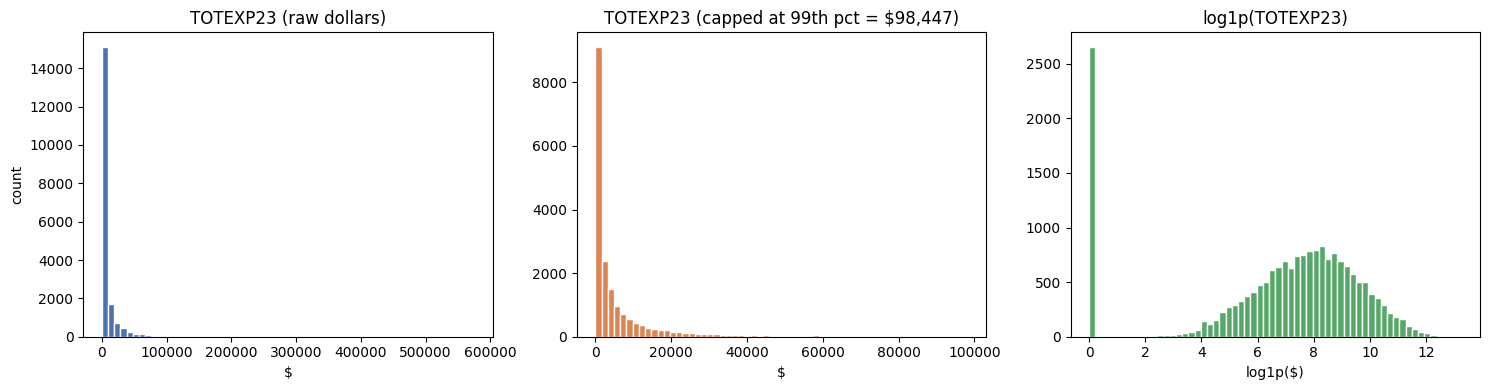

In [ ]:
# Visualize the raw target vs the log1p target.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(meps[target_var], bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_title("TOTEXP23 (raw dollars)")
axes[0].set_xlabel("$")
axes[0].set_ylabel("count")

# Same plot, capped at the 99th percentile so the long tail does not flatten the bars.
cap = meps[target_var].quantile(0.99)
axes[1].hist(meps.loc[meps[target_var] <= cap, target_var], bins=60, color="#DD8452", edgecolor="white")
axes[1].set_title(f"TOTEXP23 (capped at 99th pct = ${cap:,.0f})")
axes[1].set_xlabel("$")

axes[2].hist(meps["TOTEXP23_log1p"], bins=60, color="#55A868", edgecolor="white")
axes[2].set_title("log1p(TOTEXP23)")
axes[2].set_xlabel("log1p($)")

plt.tight_layout()
plt.show()

## Filter to adults and save the first target-cleaned file

`TOTEXP23` is observed for every person in the consolidated file, so no rows are dropped for the target itself. The MEPS file does include children, but our NHIS Part I work is built on the Sample Adult file, so we restrict MEPS to adults (`AGE23X >= 18`) here to keep both parts on a comparable population and to avoid pulling in child-only variables by accident. The `>= 18` cutoff also naturally excludes any negative reserved codes if they appear on `AGE23X`.

In [ ]:
print("Rows before adult filter:", meps.shape[0])
print("Target NaN count:        ", meps[target_var].isna().sum())

# Restrict to adults to align scope with the NHIS Part I Sample Adult file.
adult_mask = meps["AGE23X"] >= 18
clean_target_meps = meps.loc[adult_mask].copy()

print("Rows after adult filter: ", clean_target_meps.shape[0])
print("Adult share:             ", f"{clean_target_meps.shape[0] / meps.shape[0]:.1%}")

output_path = DATA_INTERIM / "meps_adult_target_cleaned.csv"
clean_target_meps.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Saved shape:", clean_target_meps.shape)

Rows before adult filter: 18919
Target NaN count:         0
Rows after adult filter:  15123
Adult share:              79.9%
Saved: /content/drive/MyDrive/med_project/data/interim/meps_adult_target_cleaned.csv
Saved shape: (15123, 1375)


## Candidate variables for the first cleaning pass

The first cleaning pass starts with variables that are plausible drivers of total health spending: demographics, income/poverty, health need (chronic conditions, perceived health, mental health screens), functioning/disability, insurance, access (usual source of care), and the cost-related access barriers from Part I — kept here as **predictors**, not the target.

The raw MEPS file contains reserved response codes. These codes need to be handled carefully because they do not all mean the same thing. Per the codebook, MEPS uses negative reserved values: `-1` (inapplicable), `-7` (refused), `-8` (don't know), `-9` (not ascertained), and `-15` (cannot be computed). These should not be treated as ordinary numeric values.

The functioning/disability candidates are split into two conceptual groups so they can be summarized as separate features later: **limitation indicators** (`*LIM31`) ask whether the person has any limitation in a domain, and **serious-difficulty indicators** (`DF*42`) ask whether the person has serious difficulty performing a specific physical or sensory function (the Census six-item disability set). In HC-251 both groups are coded as binary 1=YES / 2=NO per the codebook.

In [ ]:
# Core variables for the first MEPS cleaning pass.
# These are grouped by role so the keep/drop logic stays readable.

id_design_vars = [
    "DUPERSID",
    "PANEL",
    "DATAYEAR",
    "PERWT23F",
    "VARSTR",
    "VARPSU",
]

target_vars = ["TOTEXP23", "TOTEXP23_log1p"]

demographic_vars = [
    "AGE23X",
    "SEX",
    "RACETHX",
    "HISPANX",
    "MARRY23X",
    "REGION23",
    "EDUCYR",
    "HIDEG",
    "BORNUSA",
    "FAMSZEYR",
]

# POVCAT23 is the primary poverty feature (categorical, easy to explain).
# POVLEV23 is kept here for the interim file as a sensitivity option but will be
# dropped from the final model-ready file to avoid collinearity with POVCAT23.
income_vars = [
    "POVCAT23",
    "POVLEV23",
    "FOODST23",
]

health_need_vars = [
    "RTHLTH42",
    "MNHLTH42",
    "K6SUM42",
    "PHQ242",
    "ADINTR42",
    "ADDPRS42",
    "HIBPDX",
    "CHOLDX",
    "DIABDX_M18",
    "ASTHDX",
    "ARTHDX",
    "CANCERDX",
    "CHDDX",
    "STRKDX",
    "EMPHDX",
]

# Two functioning/disability sub-groups, both binary in HC-251.
limitation_indicator_vars = [
    "WLKLIM31",
    "ACTLIM31",
    "WRKLIM31",
    "SOCLIM31",
    "COGLIM31",
]

physical_difficulty_vars = [
    "DFHEAR42",
    "DFSEE42",
    "DFCOG42",
    "DFWLKC42",
    "DFDRSB42",
    "DFERND42",
]

# ANYLMI23 is a derived any-limitation summary; kept as its own predictor and
# excluded from the limitation_indicator count to avoid mechanical double-counting.
functioning_vars = limitation_indicator_vars + physical_difficulty_vars + ["ANYLMI23"]

insurance_access_vars = [
    "INSCOPE",
    "INSC1231",
    "HAVEUS42",
    "OFFER31X",
    "HELD31X",
]

# Cost-related access-barrier variables. In Part I (NHIS) these were the target.
# In Part II they are kept as predictors / descriptive access variables.
access_barrier_vars = [
    "DLAYCA42",
    "AFRDCA42",
    "DLAYPM42",
    "AFRDPM42",
    "DLAYDN42",
    "AFRDDN42",
]

candidate_vars = (
    id_design_vars
    + target_vars
    + demographic_vars
    + income_vars
    + health_need_vars
    + functioning_vars
    + insurance_access_vars
    + access_barrier_vars
)

candidate_vars = list(dict.fromkeys(candidate_vars))

missing_candidate_vars = [col for col in candidate_vars if col not in clean_target_meps.columns]
available_candidate_vars = [col for col in candidate_vars if col in clean_target_meps.columns]

print("Candidate variables requested:", len(candidate_vars))
print("Candidate variables available:", len(available_candidate_vars))
print("Candidate variables missing:", len(missing_candidate_vars))

if missing_candidate_vars:
    print("\nMissing variables:")
    print(missing_candidate_vars)

Candidate variables requested: 59
Candidate variables available: 59
Candidate variables missing: 0


## First analytic subset

The first subset keeps only the target, identifiers needed for merging or survey-aware checks, and the first set of candidate predictors. The survey weight and design variables are retained in the file but will not be used as model predictors.

In [ ]:
meps_first_pass = clean_target_meps[available_candidate_vars].copy()

print("First-pass MEPS shape:", meps_first_pass.shape)
meps_first_pass.head()

First-pass MEPS shape: (15123, 59)


,DUPERSID,PANEL,DATAYEAR,PERWT23F,VARSTR,VARPSU,TOTEXP23,TOTEXP23_log1p,AGE23X,SEX,...,INSC1231,HAVEUS42,OFFER31X,HELD31X,DLAYCA42,AFRDCA42,DLAYPM42,AFRDPM42,DLAYDN42,AFRDDN42
0,2790002101,27,2023,11664.426815,2019,1,646,6.472346,58,2,...,1,1,1,1,2,2,2,2,1,1
1,2790002102,27,2023,32212.113596,2019,1,1894,7.546974,27,1,...,1,2,1,1,2,2,2,2,2,2
2,2790004101,27,2023,21944.142826,2084,1,986,6.894670,49,2,...,1,1,1,1,2,2,2,2,2,2
3,2790006101,27,2023,10328.009530,2113,1,1312,7.180070,75,2,...,1,1,-1,-1,2,2,2,2,1,1
4,2790006102,27,2023,17430.521357,2113,1,0,0.000000,23,1,...,1,2,2,2,2,2,2,2,2,2


## Missingness overview

Missingness in MEPS comes from several sources: true missing data, skip patterns, and reserved response codes. The first overview checks standard missing values already stored as `NaN`. Reserved codes are handled separately after the value distributions are reviewed.

In [ ]:
missing_summary = (
    meps_first_pass
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_count"})
)

missing_summary["missing_rate"] = missing_summary["missing_count"] / len(meps_first_pass)

missing_summary = missing_summary.sort_values("missing_rate", ascending=False)

missing_summary.head(25)

,variable,missing_count,missing_rate
0,DUPERSID,0,0.0
1,PANEL,0,0.0
2,DATAYEAR,0,0.0
3,PERWT23F,0,0.0
4,VARSTR,0,0.0
5,VARPSU,0,0.0
6,TOTEXP23,0,0.0
7,TOTEXP23_log1p,0,0.0
8,AGE23X,0,0.0
9,SEX,0,0.0


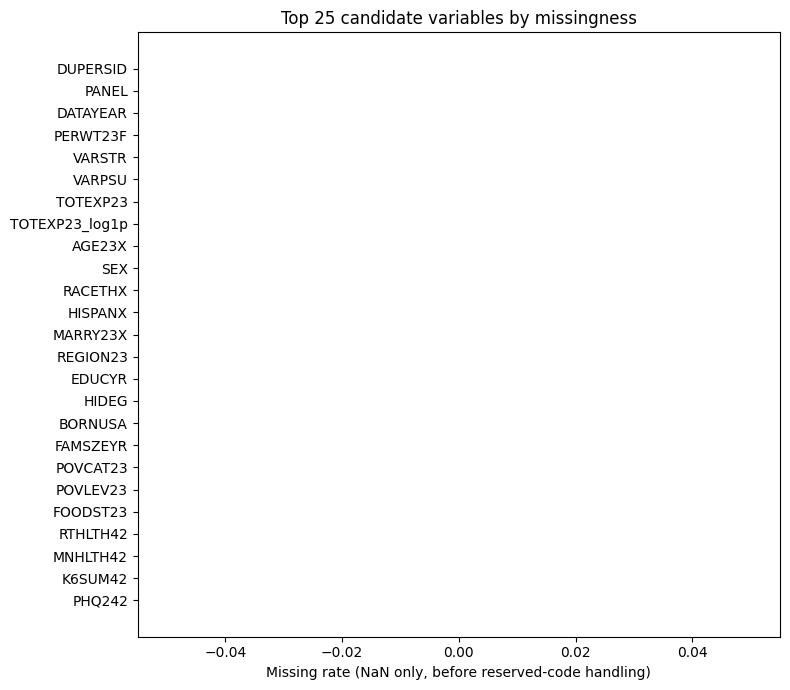

In [ ]:
# Plot the top-25 variables by NaN missing rate to see distribution at a glance.
top_missing = missing_summary.head(25)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_missing["variable"], top_missing["missing_rate"], color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("Missing rate (NaN only, before reserved-code handling)")
ax.set_title("Top 25 candidate variables by missingness")
plt.tight_layout()
plt.show()

## Value checks for candidate variables

The next tables show the raw value counts for the candidate variables. These checks help identify sparse variables, skip-pattern variables, and reserved response codes before any recoding is applied. In MEPS the negative reserved values (`-1`, `-7`, `-8`, `-9`, `-15`) appear directly in these counts, which makes them easy to spot.

In [ ]:
def show_value_counts(df, columns, max_unique=20):
    for col in columns:
        if col not in df.columns:
            continue

        unique_count = df[col].nunique(dropna=False)
        print("\n" + "=" * 80)
        print(f"{col} | unique values: {unique_count}")

        if unique_count <= max_unique:
            print(df[col].value_counts(dropna=False).sort_index())
        else:
            print(df[col].describe())


review_groups = {
    "Target": target_vars,
    "Demographics": demographic_vars,
    "Income": income_vars,
    "Health need": health_need_vars,
    "Functioning - limitation indicators": limitation_indicator_vars + ["ANYLMI23"],
    "Functioning - serious difficulty": physical_difficulty_vars,
    "Insurance and access": insurance_access_vars,
    "Access barriers (predictors)": access_barrier_vars,
}

for group_name, cols in review_groups.items():
    print("\n\n" + "#" * 100)
    print(group_name)
    print("#" * 100)
    show_value_counts(meps_first_pass, cols)



####################################################################################################
Target
####################################################################################################

TOTEXP23 | unique values: 8362
count     15123.000000
mean       9634.878728
std       23302.553321
min           0.000000
25%         399.000000
50%        2458.000000
75%        8714.500000
max      574675.000000
Name: TOTEXP23, dtype: float64

TOTEXP23_log1p | unique values: 8362
count    15123.000000
mean         6.941272
std          3.202384
min          0.000000
25%          5.991465
50%          7.807510
75%          9.072858
max         13.261562
Name: TOTEXP23_log1p, dtype: float64


####################################################################################################
Demographics
####################################################################################################

AGE23X | unique values: 68
count    15123.000000
mean        51.835086
st

## Simple distribution and target-relationship plots (raw codes)

Quick distribution plots help confirm that key predictors look reasonable against the codebook. Age should peak in working-age adults; perceived mental-health status (`MNHLTH42`) should run from 1 (Excellent) to 5 (Poor) with reserved negatives; the K6 score (`K6SUM42`) ranges from 0 to 24 with `-1` for inapplicable and `-15` for cannot-be-computed cases.

These plots are computed before reserved-code cleaning, so reserved codes (`-15`, `-8`, `-7`, `-1`) appear as their own bars. They are useful as a data-quality check, not as a substantive read on the predictor → spending relationship — that comes after reserved-code cleaning a few cells below.

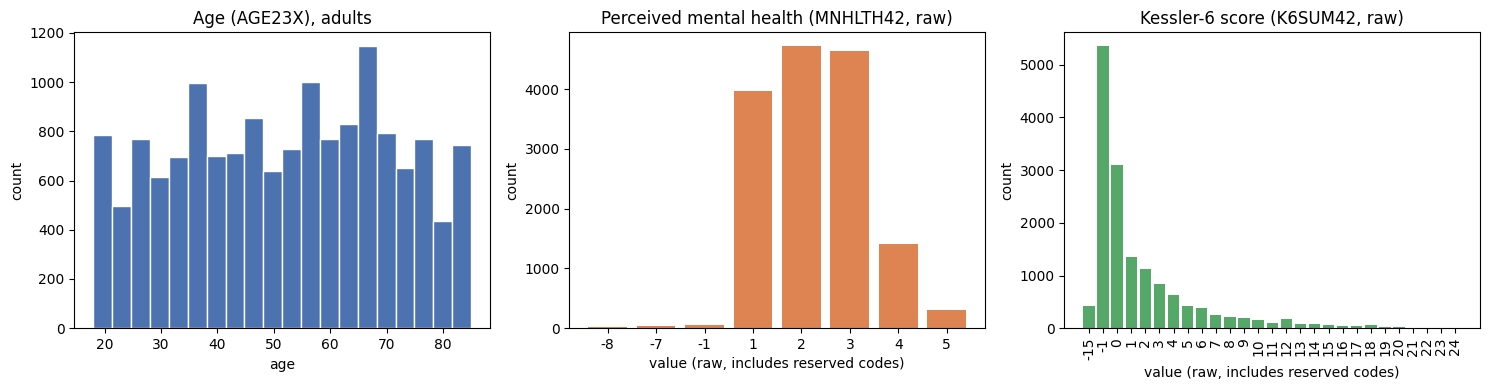

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution (after adult filter, range starts at 18).
if "AGE23X" in meps_first_pass.columns:
    age_clean = meps_first_pass["AGE23X"].dropna()
    axes[0].hist(age_clean, bins=20, color="#4C72B0", edgecolor="white")
    axes[0].set_title("Age (AGE23X), adults")
    axes[0].set_xlabel("age")
    axes[0].set_ylabel("count")

# Perceived mental health status (1=Excellent ... 5=Poor; negatives are reserved).
if "MNHLTH42" in meps_first_pass.columns:
    mh_counts = meps_first_pass["MNHLTH42"].value_counts(dropna=False).sort_index()
    axes[1].bar(mh_counts.index.astype(str), mh_counts.values, color="#DD8452")
    axes[1].set_title("Perceived mental health (MNHLTH42, raw)")
    axes[1].set_xlabel("value (raw, includes reserved codes)")
    axes[1].set_ylabel("count")

# K6 score distribution.
if "K6SUM42" in meps_first_pass.columns:
    k6_counts = meps_first_pass["K6SUM42"].value_counts(dropna=False).sort_index()
    axes[2].bar(k6_counts.index.astype(str), k6_counts.values, color="#55A868")
    axes[2].set_title("Kessler-6 score (K6SUM42, raw)")
    axes[2].set_xlabel("value (raw, includes reserved codes)")
    axes[2].set_ylabel("count")
    for label in axes[2].get_xticklabels():
        label.set_rotation(90)

plt.tight_layout()
plt.show()

         mean_log1p_spend     n
age_bin                        
18-24                4.86  1279
25-34                5.55  2075
35-44                6.10  2406
45-54                6.71  2223
55-64                7.48  2601
65-74                8.22  2589
75+                  8.67  1950


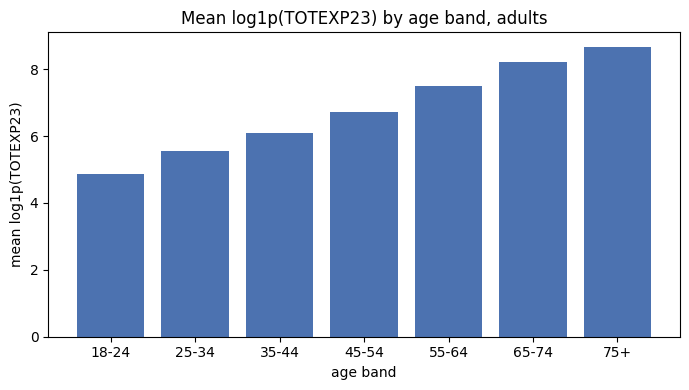

In [ ]:
# Mean log1p spending by 10-year age band - basic age gradient sanity check.
# Adult-only file means the lowest band starts at 18.
if "AGE23X" in meps_first_pass.columns:
    age_bins = pd.cut(
        meps_first_pass["AGE23X"],
        bins=[17, 24, 34, 44, 54, 64, 74, 120],
        labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"],
    )
    spend_by_age = (
        meps_first_pass.assign(age_bin=age_bins)
        .groupby("age_bin", observed=True)["TOTEXP23_log1p"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "mean_log1p_spend", "count": "n"})
    )
    print(spend_by_age.round(2))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(spend_by_age.index.astype(str), spend_by_age["mean_log1p_spend"], color="#4C72B0")
    ax.set_title("Mean log1p(TOTEXP23) by age band, adults")
    ax.set_xlabel("age band")
    ax.set_ylabel("mean log1p(TOTEXP23)")
    plt.tight_layout()
    plt.show()

## Reserved code cleaning rules

MEPS uses negative reserved response codes for values such as inapplicable, refused, don't know, not ascertained, and cannot be computed. Unlike NHIS, where reserved codes can collide with valid category numbers, MEPS reserved codes are negative and therefore safe to recode in one consistent rule for nominal/ordinal categorical variables.

Two cautions:

1. Continuous variables that can legitimately take zero or small positive values (income, K6 score, age) must be recoded carefully — `-1` and `-15` are reserved, but `0` is a real value.
2. The K6 score (`K6SUM42`) and PHQ-2 score (`PHQ242`) use `-1 = INAPPLICABLE` and `-15 = CANNOT BE COMPUTED`; everything else is a true score (0 through 24 for K6).
3. The target `TOTEXP23` is left unchanged here — it is a constructed dollar field with no reserved codes.

In [ ]:
meps_clean_step1 = meps_first_pass.copy()

# Negative reserved codes used in MEPS HC-251.
reserved_codes_meps = [-1, -7, -8, -9, -15]

categorical_recode_vars = [
    "SEX",
    "RACETHX",
    "HISPANX",
    "MARRY23X",
    "REGION23",
    "HIDEG",
    "BORNUSA",
    "RTHLTH42",
    "MNHLTH42",
    "ADINTR42",
    "ADDPRS42",
    "HIBPDX",
    "CHOLDX",
    "DIABDX_M18",
    "ASTHDX",
    "ARTHDX",
    "CANCERDX",
    "CHDDX",
    "STRKDX",
    "EMPHDX",
    "WLKLIM31",
    "ACTLIM31",
    "WRKLIM31",
    "SOCLIM31",
    "COGLIM31",
    "DFHEAR42",
    "DFSEE42",
    "DFCOG42",
    "DFWLKC42",
    "DFDRSB42",
    "DFERND42",
    "ANYLMI23",
    "INSCOPE",
    "INSC1231",
    "HAVEUS42",
    "DLAYCA42",
    "AFRDCA42",
    "DLAYPM42",
    "AFRDPM42",
    "DLAYDN42",
    "AFRDDN42",
    "OFFER31X",
    "HELD31X",
    "FOODST23",
    "POVCAT23",
]

for col in categorical_recode_vars:
    if col in meps_clean_step1.columns:
        meps_clean_step1[col] = meps_clean_step1[col].replace(
            {code: np.nan for code in reserved_codes_meps}
        )

# Score and continuous variables: recode reserved codes only, keep zeros.
score_continuous_vars = [
    "AGE23X",
    "EDUCYR",
    "FAMSZEYR",
    "K6SUM42",
    "PHQ242",
    "POVLEV23",
]

for col in score_continuous_vars:
    if col in meps_clean_step1.columns:
        meps_clean_step1[col] = meps_clean_step1[col].replace(
            {code: np.nan for code in reserved_codes_meps}
        )

print("Reserved-code cleaning complete.")

Reserved-code cleaning complete.


## Mental-health relationship plots after reserved-code cleaning

Repeat the `MNHLTH42` and `K6SUM42` relationship views using the cleaned frame. Now that the negative reserved codes (`-15`, `-8`, `-7`, `-1`) have been mapped to `NaN`, only valid response categories remain — `MNHLTH42` runs 1 (Excellent) to 5 (Poor), and `K6SUM42` runs 0 to 24. These post-cleaning plots are the ones to read substantively; the earlier raw-code plots were only data-quality checks.

          mean_log1p_spend  mean_raw_spend     n
MNHLTH42                                        
1.0                   6.54         7432.25  3960
2.0                   6.97         8213.72  4714
3.0                   7.03        10783.38  4635
4.0                   7.74        14954.29  1407
5.0                   8.23        21327.90   297


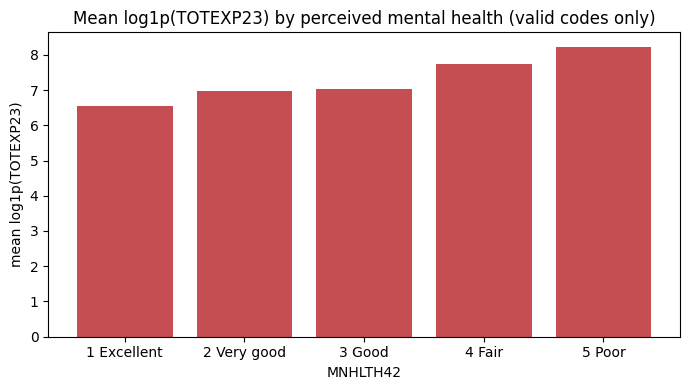

In [ ]:
# Mean log1p spending by perceived mental health status, valid codes only.
if "MNHLTH42" in meps_clean_step1.columns:
    spend_by_mh = (
        meps_clean_step1.dropna(subset=["MNHLTH42"])
        .groupby("MNHLTH42")
        .agg(
            mean_log1p_spend=("TOTEXP23_log1p", "mean"),
            mean_raw_spend=("TOTEXP23", "mean"),
            n=("TOTEXP23", "size"),
        )
        .sort_index()
    )
    mh_labels = {1: "1 Excellent", 2: "2 Very good", 3: "3 Good", 4: "4 Fair", 5: "5 Poor"}
    print(spend_by_mh.round(2))

    fig, ax = plt.subplots(figsize=(7, 4))
    x_labels = [mh_labels.get(int(v), str(v)) for v in spend_by_mh.index]
    ax.bar(x_labels, spend_by_mh["mean_log1p_spend"], color="#C44E52")
    ax.set_title("Mean log1p(TOTEXP23) by perceived mental health (valid codes only)")
    ax.set_xlabel("MNHLTH42")
    ax.set_ylabel("mean log1p(TOTEXP23)")
    plt.tight_layout()
    plt.show()

                 mean_log1p_spend     n
k6_band                                
0-4 (low)                    7.27  7032
5-12 (moderate)              7.96  1899
13-24 (serious)              8.19   424


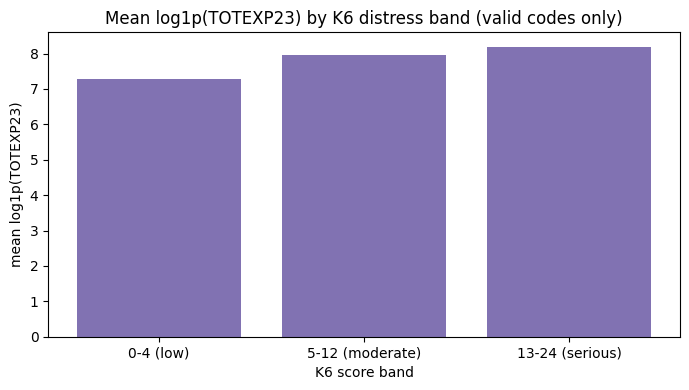

In [ ]:
# Mean log1p spending by K6 band, valid codes only.
# K6 thresholds in common use: 0-4 no/low distress, 5-12 moderate, 13-24 serious.
if "K6SUM42" in meps_clean_step1.columns:
    k6_clean = meps_clean_step1.dropna(subset=["K6SUM42"]).copy()
    k6_clean["k6_band"] = pd.cut(
        k6_clean["K6SUM42"],
        bins=[-0.1, 4, 12, 24],
        labels=["0-4 (low)", "5-12 (moderate)", "13-24 (serious)"],
    )
    spend_by_k6 = (
        k6_clean.groupby("k6_band", observed=True)["TOTEXP23_log1p"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "mean_log1p_spend", "count": "n"})
    )
    print(spend_by_k6.round(2))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(spend_by_k6.index.astype(str), spend_by_k6["mean_log1p_spend"], color="#8172B2")
    ax.set_title("Mean log1p(TOTEXP23) by K6 distress band (valid codes only)")
    ax.set_xlabel("K6 score band")
    ax.set_ylabel("mean log1p(TOTEXP23)")
    plt.tight_layout()
    plt.show()

## Missingness after reserved-code recoding

The updated missingness table shows how much information is lost after reserved codes are treated as missing. Variables with heavy missingness will need a keep/drop decision before modeling — the K6 score, for example, is collected only on adult SAQ respondents, so it carries a structurally large `INAPPLICABLE` share.

In [ ]:
missing_after_reserved = (
    meps_clean_step1
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_count"})
)

missing_after_reserved["missing_rate"] = missing_after_reserved["missing_count"] / len(meps_clean_step1)

missing_after_reserved = missing_after_reserved.sort_values("missing_rate", ascending=False)

missing_after_reserved.head(30)

,variable,missing_count,missing_rate
38,WRKLIM31,13430,0.888051
51,OFFER31X,7632,0.504662
52,HELD31X,7431,0.491371
23,K6SUM42,5768,0.381406
24,PHQ242,5711,0.377637
26,ADDPRS42,5700,0.376909
25,ADINTR42,5678,0.375455
50,HAVEUS42,673,0.044502
20,FOODST23,522,0.034517
40,COGLIM31,334,0.022086


## Initial keep/drop review table

The first review table does not make final decisions. It gives a compact view of each candidate variable, its missing rate, and a starter decision. Final decisions should use the codebook, EDA, and modeling purpose together.

For the Part II regression the keep/drop logic is:

**Keep for the model-ready file:** demographics, `POVCAT23` (primary poverty feature), health need (perceived health, mental health, K6, PHQ-2, chronic conditions), functioning/disability indicators, insurance status, access (usual source of care), and the cost-related access barriers as predictors.

**Drop from the model-ready file:**
- Identifiers (`DUPERSID`, `PANEL`, `DATAYEAR`).
- Survey weights and design variables (`PERWT23F`, `VARSTR`, `VARPSU`) — kept available in interim files but not used as predictors.
- `POVLEV23` — collinear with `POVCAT23`. Kept in the interim file for sensitivity analyses; dropped from the model-ready file.
- All other dollar expenditure variables (`TOTSLF23`, `TOTMCR23`, `TOTMCD23`, `RXEXP23`, `OBVEXP23`, ...) and event-count variables (`OBTOTV23`, `RXTOT23`, `IPDIS23`, ...) — these mechanically determine `TOTEXP23` and would leak the target.

We do not include those leakage variables in `candidate_vars` above, but the next section also enforces the drop programmatically against the *full* MEPS column list so a future expansion of the candidate set cannot accidentally re-introduce them.

In [ ]:
variable_roles = {}

for col in id_design_vars:
    variable_roles[col] = "identifier/design"
for col in target_vars:
    variable_roles[col] = "target/documentation"
for col in demographic_vars:
    variable_roles[col] = "demographic"
for col in income_vars:
    variable_roles[col] = "income/poverty"
for col in health_need_vars:
    variable_roles[col] = "health need"
for col in functioning_vars:
    variable_roles[col] = "functioning/disability"
for col in insurance_access_vars:
    variable_roles[col] = "insurance/access"
for col in access_barrier_vars:
    variable_roles[col] = "access barrier (predictor)"

review_table = missing_after_reserved.copy()
review_table["role"] = review_table["variable"].map(variable_roles).fillna("unassigned")

def starter_decision(row):
    variable = row["variable"]
    missing_rate = row["missing_rate"]

    if variable in ["DUPERSID", "PANEL", "DATAYEAR", "PERWT23F", "VARSTR", "VARPSU"]:
        return "keep for merge/EDA, exclude from model predictors"

    if variable == "TOTEXP23":
        return "target (raw)"

    if variable == "TOTEXP23_log1p":
        return "target (log1p sensitivity)"

    if variable == "POVLEV23":
        return "keep in interim only; sensitivity option for POVCAT23"

    if missing_rate >= 0.60:
        return "review; likely drop or subgroup only"

    if missing_rate >= 0.30:
        return "review before modeling"

    return "candidate predictor"

review_table["starter_decision"] = review_table.apply(starter_decision, axis=1)

review_table = review_table[
    ["variable", "role", "missing_count", "missing_rate", "starter_decision"]
].sort_values(["starter_decision", "missing_rate"], ascending=[True, False])

review_table

,variable,role,missing_count,missing_rate,starter_decision
50,HAVEUS42,insurance/access,673,0.044502,candidate predictor
20,FOODST23,income/poverty,522,0.034517,candidate predictor
40,COGLIM31,functioning/disability,334,0.022086,candidate predictor
47,ANYLMI23,functioning/disability,210,0.013886,candidate predictor
39,SOCLIM31,functioning/disability,203,0.013423,candidate predictor
37,ACTLIM31,functioning/disability,190,0.012564,candidate predictor
36,WLKLIM31,functioning/disability,182,0.012035,candidate predictor
28,CHOLDX,health need,154,0.010183,candidate predictor
14,EDUCYR,demographic,149,0.009853,candidate predictor
15,HIDEG,demographic,148,0.009786,candidate predictor


## Quick check after reserved-code cleaning

Education (`EDUCYR`, `HIDEG`), age (`AGE23X`), and the K6 / PHQ-2 scores are sanity-checked here. Their post-cleaning distributions should match the codebook value lists with the reserved codes removed.

In [ ]:
check_cols = ["AGE23X", "EDUCYR", "HIDEG", "K6SUM42", "PHQ242", "POVCAT23", "POVLEV23"]

for col in check_cols:
    if col in meps_clean_step1.columns:
        print("\n" + "=" * 80)
        print(col)
        if meps_clean_step1[col].nunique(dropna=False) <= 30:
            print(meps_clean_step1[col].value_counts(dropna=False).sort_index())
        else:
            print(meps_clean_step1[col].describe())


AGE23X
count    15123.000000
mean        51.835086
std         18.629300
min         18.000000
25%         36.000000
50%         53.000000
75%         67.000000
max         85.000000
Name: AGE23X, dtype: float64

EDUCYR
EDUCYR
0.0       43
1.0       45
2.0       54
3.0       57
4.0       58
5.0       50
6.0      186
7.0       71
8.0      223
9.0      305
10.0     384
11.0     593
12.0    4450
13.0     864
14.0    1848
15.0     459
16.0    3007
17.0    2277
NaN      149
Name: count, dtype: int64

HIDEG
HIDEG
1.0    1946
2.0     596
3.0    5657
4.0    3109
5.0    1589
6.0     535
7.0    1543
NaN     148
Name: count, dtype: int64

K6SUM42
K6SUM42
0.0     3089
1.0     1359
2.0     1118
3.0      831
4.0      635
5.0      416
6.0      390
7.0      260
8.0      221
9.0      187
10.0     148
11.0     107
12.0     170
13.0      87
14.0      71
15.0      55
16.0      51
17.0      43
18.0      52
19.0      18
20.0      20
21.0       7
22.0       7
23.0       3
24.0      10
NaN     5768
Name: cou

## Save the first cleaned candidate file

The saved file is still an interim file. It contains the cleaned target (raw and log1p) plus the first candidate predictors after reserved-code handling. `POVLEV23` is included here so a sensitivity analysis can pull the continuous poverty measure later. The next pass will refine keep/drop decisions and may bring in event-level files (medical conditions, prescribed medicines, office-based visits) as supporting layers.

In [ ]:
output_path = DATA_INTERIM / "meps_first_pass_cleaned_candidates.csv"

meps_clean_step1.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Saved shape:", meps_clean_step1.shape)

Saved: /content/drive/MyDrive/med_project/data/interim/meps_first_pass_cleaned_candidates.csv
Saved shape: (15123, 59)


## First model-ready variable decisions

The first model-ready file should be simple enough to explain and strong enough to model. Variables with heavy skip-pattern missingness are removed for the first version unless they can be converted into a clearer derived feature.

Two cases worth flagging:

- The K6 score and PHQ-2 score (`K6SUM42`, `PHQ242`, `ADINTR42`, `ADDPRS42`) come from the Self-Administered Questionnaire and are missing for everyone outside the SAQ frame. They are kept as predictors because they are central to the project topic, but the missing values are flagged with an SAQ-eligibility indicator.
- Round-3/1 functioning items (`WLKLIM31`, `ACTLIM31`, etc.) are observed in an earlier round. Missing values are kept as a separate `Unknown` category for the first pass.

In [ ]:
meps_model_ready = meps_clean_step1.copy()

## Create broader feature groups

Some variables are useful individually, while others are easier to explain as grouped indicators. The first feature engineering pass creates simple summaries for chronic conditions, mental-health screening, the two functioning sub-groups (limitation indicators vs. serious-difficulty indicators), and the cost-related access-barrier predictors.

The functioning split is conceptual: `*LIM31` items are general yes/no limitation screeners, while `DF*42` items are the Census six-item disability set asking about serious difficulty in specific physical or sensory functions. Per the HC-251 codebook both groups are coded 1=YES / 2=NO, so the same `count_yes_values` helper applies to each — but they are kept as two separate features so a later analysis can tell whether broad limitations or specific physical-difficulty domains carry more predictive weight.

In [ ]:
chronic_condition_cols = [
    "HIBPDX",
    "CHOLDX",
    "DIABDX_M18",
    "ASTHDX",
    "ARTHDX",
    "CANCERDX",
    "CHDDX",
    "STRKDX",
    "EMPHDX",
]

mental_health_screen_cols = [
    "ADINTR42",
    "ADDPRS42",
]

# Cost-related access-barrier indicators kept as a single "affordability pressure"
# count predictor.
access_barrier_count_cols = [
    "DLAYCA42",
    "AFRDCA42",
    "DLAYPM42",
    "AFRDPM42",
    "DLAYDN42",
    "AFRDDN42",
]

In [ ]:
def count_yes_values(df, columns):
    available_cols = [col for col in columns if col in df.columns]
    return (df[available_cols] == 1).sum(axis=1)


def count_phq_positive(df, columns):
    # PHQ-2 items: 0=Not at all, 1=Several days, 2=More than half the days, 3=Nearly every day.
    # Score >= 2 on either item is a common positive screen marker.
    available_cols = [col for col in columns if col in df.columns]
    return df[available_cols].isin([2, 3]).sum(axis=1)


meps_model_ready["chronic_condition_count"] = count_yes_values(
    meps_model_ready,
    chronic_condition_cols
)

meps_model_ready["mental_health_screen_count"] = count_phq_positive(
    meps_model_ready,
    mental_health_screen_cols
)

# Two separate functioning summary features.
# limitation_indicator_vars and physical_difficulty_vars are defined in the
# candidate-variables cell.
meps_model_ready["limitation_indicator_count"] = count_yes_values(
    meps_model_ready,
    limitation_indicator_vars
)

meps_model_ready["physical_difficulty_count"] = count_yes_values(
    meps_model_ready,
    physical_difficulty_vars
)

meps_model_ready["access_barrier_count"] = count_yes_values(
    meps_model_ready,
    access_barrier_count_cols
)

summary_cols = [
    "chronic_condition_count",
    "mental_health_screen_count",
    "limitation_indicator_count",
    "physical_difficulty_count",
    "access_barrier_count",
]

meps_model_ready[summary_cols].describe()

,chronic_condition_count,mental_health_screen_count,limitation_indicator_count,physical_difficulty_count,access_barrier_count
count,15123.000000,15123.000000,15123.000000,15123.000000,15123.000000
mean,1.545791,0.092442,0.496793,0.364809,0.411757
std,1.617199,0.382009,1.161095,0.869867,1.025562
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,0.000000,0.000000,0.000000,0.000000
max,9.000000,2.000000,5.000000,6.000000,6.000000


## Handle selected categorical missing values

For the first model-ready file, missing values in selected categorical predictors are kept as explicit categories. This avoids dropping many rows and keeps skip-pattern information visible.

The target is already clean, so no target rows are removed here.

In [ ]:
categorical_missing_as_unknown = [
    "HIDEG",
    "MARRY23X",
    "BORNUSA",
    "INSC1231",
    "HAVEUS42",
    "OFFER31X",
    "HELD31X",
    "POVCAT23",
]

for col in categorical_missing_as_unknown:
    if col in meps_model_ready.columns:
        meps_model_ready[col] = meps_model_ready[col].fillna("Unknown")

## Drop variables not used in the first model-ready file

Identifiers and survey design variables are removed from the model-ready file. They remain available in the interim files for merging, documentation, and weighted descriptive checks.

`POVLEV23` is dropped from the model-ready file because it is collinear with `POVCAT23`, the primary poverty feature. It stays in the interim cleaned file for any sensitivity analysis that wants the continuous % of poverty line.

All dollar expenditure variables and utilization-count variables are also enforced as drops, even if they slipped into the candidate set or get added in a future revision. These columns are mechanically tied to `TOTEXP23` and would leak the target.

In [ ]:
# Identifiers and survey design - kept in interim files, not used as predictors.
drop_id_design = [
    "DUPERSID",
    "PANEL",
    "DATAYEAR",
    "PERWT23F",
    "VARSTR",
    "VARPSU",
]

# Poverty: keep POVCAT23 as the primary feature; POVLEV23 stays in the interim
# file as a sensitivity option but is dropped here to avoid collinearity.
drop_secondary_poverty = ["POVLEV23"]

# All other dollar expenditure variables: any 2023 expenditure or payment-source
# variable by event type (TOT/OB/OP/ER/IP/HH/DV/VIS/RX/OTH) leaks the target.
# Suffixes seen in the codebook: EXP, SLF, MCR, MCD, PRV, VA, TRI, OFD, STL, WCP,
# OSR, PTR, OTH, TCH (charges).
expenditure_prefixes = (
    "TOT", "OB", "OP", "ER", "IP", "HH", "DV", "VIS", "RX", "OTH",
)
expenditure_suffixes_23 = (
    "EXP23", "SLF23", "MCR23", "MCD23", "PRV23", "VA23", "TRI23",
    "OFD23", "STL23", "WCP23", "OSR23", "PTR23", "OTH23", "TCH23",
)

def is_expenditure_var(col):
    if not col.endswith(expenditure_suffixes_23):
        return False
    return col.startswith(expenditure_prefixes)

# Utilization counts that map almost mechanically into spend.
utilization_count_vars = [
    "OBTOTV23", "OBDRV23",
    "OPTOTV23", "OPDRV23",
    "ERTOT23",
    "IPDIS23", "IPNGTD23",
    "DVTOT23",
    "HHTOTD23", "HHAGD23", "HHINDD23", "HHINFD23",
    "RXTOT23",
]

# Build the full drop list against the full MEPS column space, then intersect with
# what is actually present in the model-ready frame so the drop call is safe.
all_meps_cols = list(meps.columns)

leakage_expenditure_cols = [c for c in all_meps_cols if is_expenditure_var(c) and c != "TOTEXP23"]
leakage_utilization_cols = [c for c in utilization_count_vars if c in all_meps_cols]

drop_for_model_ready = (
    drop_id_design
    + drop_secondary_poverty
    + leakage_expenditure_cols
    + leakage_utilization_cols
)
drop_for_model_ready = [c for c in dict.fromkeys(drop_for_model_ready) if c in meps_model_ready.columns]

print(f"Identifier/design columns to drop:    {len(drop_id_design)}")
print(f"Secondary poverty (POVLEV23) drop:    {len(drop_secondary_poverty)}")
print(f"Leakage expenditure cols (full file): {len(leakage_expenditure_cols)}")
print(f"Leakage utilization cols (full file): {len(leakage_utilization_cols)}")
print(f"Of those, present in model-ready set: {len(drop_for_model_ready)}")

meps_model_ready = meps_model_ready.drop(columns=drop_for_model_ready)

print("\nModel-ready shape:", meps_model_ready.shape)
print("\nRemaining columns:")
print(meps_model_ready.columns.tolist())

Identifier/design columns to drop:    6
Secondary poverty (POVLEV23) drop:    1
Leakage expenditure cols (full file): 278
Leakage utilization cols (full file): 13
Of those, present in model-ready set: 7

Model-ready shape: (15123, 57)

Remaining columns:
['TOTEXP23', 'TOTEXP23_log1p', 'AGE23X', 'SEX', 'RACETHX', 'HISPANX', 'MARRY23X', 'REGION23', 'EDUCYR', 'HIDEG', 'BORNUSA', 'FAMSZEYR', 'POVCAT23', 'FOODST23', 'RTHLTH42', 'MNHLTH42', 'K6SUM42', 'PHQ242', 'ADINTR42', 'ADDPRS42', 'HIBPDX', 'CHOLDX', 'DIABDX_M18', 'ASTHDX', 'ARTHDX', 'CANCERDX', 'CHDDX', 'STRKDX', 'EMPHDX', 'WLKLIM31', 'ACTLIM31', 'WRKLIM31', 'SOCLIM31', 'COGLIM31', 'DFHEAR42', 'DFSEE42', 'DFCOG42', 'DFWLKC42', 'DFDRSB42', 'DFERND42', 'ANYLMI23', 'INSCOPE', 'INSC1231', 'HAVEUS42', 'OFFER31X', 'HELD31X', 'DLAYCA42', 'AFRDCA42', 'DLAYPM42', 'AFRDPM42', 'DLAYDN42', 'AFRDDN42', 'chronic_condition_count', 'mental_health_screen_count', 'limitation_indicator_count', 'physical_difficulty_count', 'access_barrier_count']


## Final missingness check before saving

The first model-ready file should have no missing target values. Predictor missingness should be limited and explainable. Any remaining missing values will be handled inside the modeling pipeline using imputation.

In [ ]:
final_missing = (
    meps_model_ready
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_count"})
)

final_missing["missing_rate"] = final_missing["missing_count"] / len(meps_model_ready)
final_missing = final_missing.sort_values("missing_rate", ascending=False)

final_missing.head(25)

,variable,missing_count,missing_rate
31,WRKLIM31,13430,0.888051
16,K6SUM42,5768,0.381406
17,PHQ242,5711,0.377637
19,ADDPRS42,5700,0.376909
18,ADINTR42,5678,0.375455
13,FOODST23,522,0.034517
33,COGLIM31,334,0.022086
40,ANYLMI23,210,0.013886
32,SOCLIM31,203,0.013423
30,ACTLIM31,190,0.012564


## Save the first MEPS model-ready file

The saved file is the first regression-ready version for Part II. It is restricted to adults (`AGE23X >= 18`) to match the NHIS Sample Adult scope, uses `POVCAT23` as the primary poverty feature, and excludes `POVLEV23` plus all dollar/utilization columns that would leak `TOTEXP23`. It can be revised after the event-level MEPS files (medical conditions, prescribed medicines, office-based visits, hospital inpatient) are merged, but it is strong enough for an initial baseline regression model on `TOTEXP23` and on `log1p(TOTEXP23)`.

In [ ]:
output_path = DATA_PROCESSED / "meps_model_ready_v1.csv"

meps_model_ready.to_csv(output_path, index=False)

print("Saved:", output_path)
print("Saved shape:", meps_model_ready.shape)

Saved: /content/drive/MyDrive/med_project/data/processed/meps_model_ready_v1.csv
Saved shape: (15123, 57)
